<a href="https://colab.research.google.com/github/newton-dai/Low-Mun/blob/main/issm_wks1_2__TAILOWMUN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **i. Mount google drive**
---

In [104]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## **ii. Import the libraries**
---

In [105]:
import cv2
import sys
import os
import scipy
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("Versions of key libraries")
print("---")
print("numpy:     ", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:    ", pd.__version__)
print("scipy:     ", scipy.__version__)


Versions of key libraries
---
numpy:      2.1.3
matplotlib: 3.10.0
pandas:     2.2.3
scipy:      1.16.3


## **iii. Append /iss/issm/data/ in your python path**
---

In [106]:
sys.path.append('/content/gdrive/My Drive/iss/issm/data/')
print("All the system paths:")
sys.path

All the system paths:


['/content',
 '/env/python',
 '/usr/lib/python313.zip',
 '/usr/lib/python3.13',
 '/usr/lib/python3.13/lib-dynload',
 '',
 '/usr/local/lib/python3.13/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.13/dist-packages/IPython/extensions',
 '/root/.ipython',
 '/content/gdrive/My Drive/iss/issm/data/',
 '/content/gdrive/My Drive/iss/issm/data/',
 '/content/gdrive/My Drive/iss/issm/data/',
 '/content/gdrive/My Drive/iss/issm/data/',
 '/content/gdrive/My Drive/iss/issm/data/',
 '/content/gdrive/My Drive/iss/issm/data/',
 '/content/gdrive/My Drive/iss/issm/data/']

## **iv. Change working directory to /iss/issm/data/**
---

In [107]:
os.chdir('/content/gdrive/My Drive/iss/issm/data/')
print("Current working directory:")
os.getcwd()

Current working directory:


'/content/gdrive/My Drive/iss/issm/data'

## **v. Setup matplotlib**
---

In [108]:
plt.style.use('ggplot')                   # if want to use the default style, set 'classic'
plt.rcParams['ytick.right']     = True
plt.rcParams['ytick.labelright']= True
plt.rcParams['ytick.left']      = False
plt.rcParams['ytick.labelleft'] = False

print("Matplotlib setup completes.")

Matplotlib setup completes.


## **1. Part 1: Perform peak detection**
---
* Step 1: Read in the ecg signals
* Step 2: Perform peak detection
* Step 3: Display detected peaks

In [109]:
# Part 1: Perform Peak Detection

from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd

# Step 1: Read in the ECG signal
# Search for the ECG data file in the current working directory

files = os.listdir('.')
print("Files in the current directory:")
print(files)

# Load the ECG signal
# Change the filename below if your NUS-ISS ECG file has a different name.
ecg_signal = pd.read_csv('ecg1D.csv', header=None)

# Make sure the signal is a 1-D NumPy array
ecg_signal = np.asarray(ecg_signal).squeeze()

print("ECG signal loaded successfully from 'ecg1D.csv'.")
print("Signal shape:", ecg_signal.shape)
print("Number of samples:", len(ecg_signal))


Files in the current directory:
['ecg2D.csv', 'ecg1D.csv', 'GDP.csv']
ECG signal loaded successfully from 'ecg1D.csv'.
Signal shape: (1440,)
Number of samples: 1440


### Peak Detection

Now, let's use `scipy.signal.find_peaks` to detect peaks in the ECG signal. We'll use a `height` parameter to define the minimum amplitude of peaks to be detected and a `distance` parameter to specify the minimum horizontal distance between adjacent peaks.

In [110]:
# Step 2: Perform peak detection
from scipy.signal import find_peaks

# Adjust these parameters based on your specific ECG signal characteristics
# 'height' defines the minimum amplitude to be considered a peak
# 'distance' defines the minimum number of samples between peaks
peaks, _ = find_peaks(ecg_signal, height=0.5, distance=100)

print(f'Detected {len(peaks)} peaks.')

Detected 8 peaks.


### Display Detected Peaks

Finally, we'll plot the ECG signal and mark the detected peaks to visualize the results.

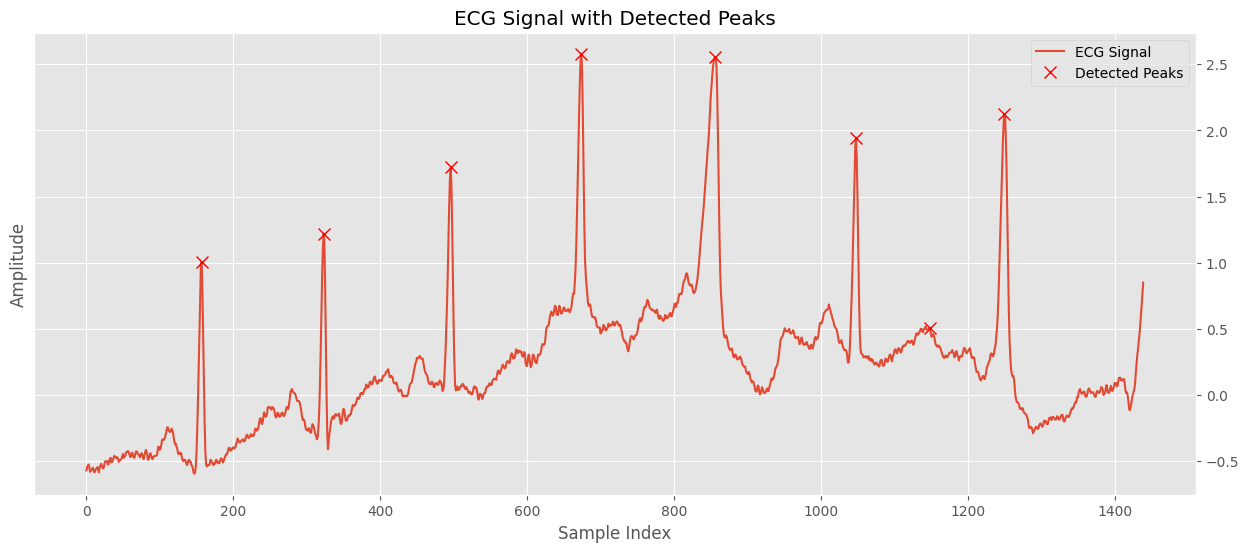

In [111]:
# Step 3: Display detected peaks
plt.figure(figsize=(15, 6))
plt.plot(ecg_signal, label='ECG Signal')
plt.plot(peaks, ecg_signal[peaks], "x", color='red', markersize=8, label='Detected Peaks')
plt.title('ECG Signal with Detected Peaks')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

**Parameter Selection:**

A minimum peak height of 0.5 was selected to identify the prominent peaks in the ECG signal while reducing the detection of smaller fluctuations. A minimum distance of 100 samples was used to reduce the likelihood of detecting multiple peaks within the same heartbeat.

**Interpretation**:

The detected peaks correspond to the prominent high-amplitude points in the original ECG signal. The peak markers show that the find_peaks() method is able to identify the major peaks while reducing the detection of smaller signal fluctuations.

## **Part 2: Baseline correction**
---
* Step 1: Create the baseline correction function
* Step 2: Perform baseline correction
* Step 3: Display the output

In [112]:
# Step 1: Create the baseline correction function
from scipy.signal import savgol_filter # Ensure savgol_filter is imported here

def baseline_correction(signal, window_length=101, polyorder=3):
    """
    Perform baseline correction using a Savitzky-Golay filter.

    Args:
        signal (np.array): The input signal.
        window_length (int): The length of the filter window (must be odd).
        polyorder (int): The order of the polynomial used to fit the samples (must be less than window_length).

    Returns:
        np.array: The baseline-corrected signal.
        np.array: The estimated baseline.
    """
    # Estimate the baseline
    baseline = savgol_filter(
        signal,
        window_length=window_length,
        polyorder=polyorder
    )

    # Remove the estimated baseline from the original signal
    corrected_signal = signal - baseline

    return corrected_signal, baseline

print("Baseline correction function `baseline_correction` defined.")

Baseline correction function `baseline_correction` defined.


In [113]:
# Step 2: Perform baseline correction

# Make sure the window length is odd and smaller than the signal length
window_length = 101 # Default or chosen window length
polyorder = 3       # Default or chosen polynomial order

# Adjust window_length if it's too large for the signal
if window_length >= len(ecg_signal):
    window_length = len(ecg_signal) - 1
    if window_length % 2 == 0:
        window_length -= 1 # Ensure it's odd

# Adjust polyorder if it's not less than window_length
if polyorder >= window_length:
    polyorder = window_length - 1
    if polyorder < 1:
        polyorder = 1 # Minimum polyorder is 1

corrected_ecg_signal, baseline_estimate = baseline_correction(
    ecg_signal,
    window_length=window_length,
    polyorder=polyorder
)

print("Baseline correction completed.")
print("Window length:", window_length)
print("Polynomial order:", polyorder)

Baseline correction completed.
Window length: 101
Polynomial order: 3


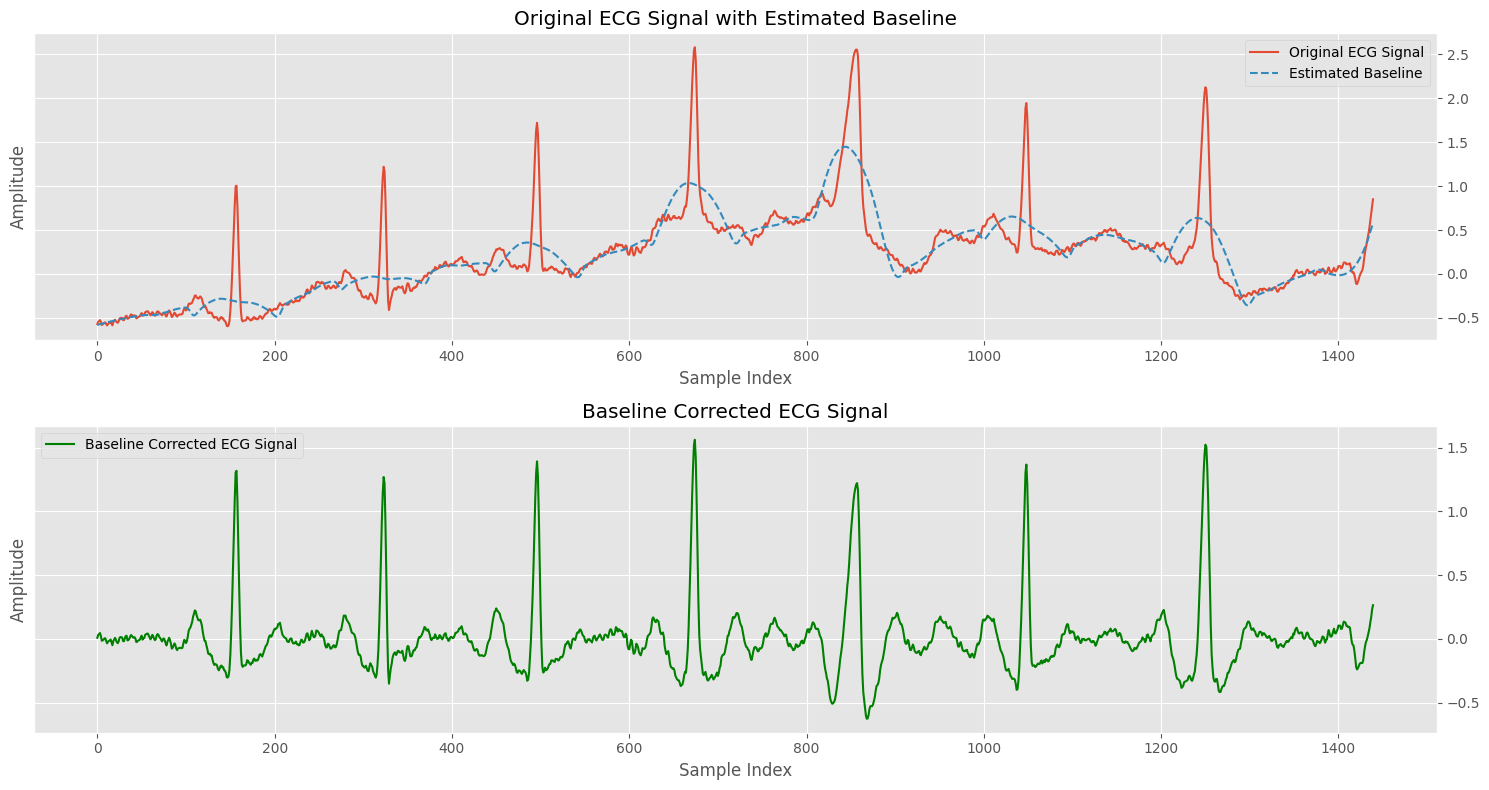

In [114]:
# Step 3: Display the output
plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
plt.plot(ecg_signal, label='Original ECG Signal')
plt.plot(
    baseline_estimate,
    '--',
    label='Estimated Baseline'
)
plt.title('Original ECG Signal with Estimated Baseline')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(
    corrected_ecg_signal,
    label='Baseline Corrected ECG Signal',
    color='green' # Added color for clarity
)
plt.title('Baseline Corrected ECG Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Parameter Selection:**

A window length of 101 samples was used to estimate the slowly varying baseline while retaining the main ECG waveform characteristics. A polynomial order of 3 was selected to provide a smooth baseline estimate without using an unnecessarily complex polynomial.

**Interpretation:**

The estimated baseline captures the slowly varying trend in the original ECG signal. Subtracting this baseline produces a corrected ECG signal centred more closely around zero, while retaining the main waveform characteristics.

## **Part 3: Signal Denoising**
---
* Step 1: Create the denoising function (e.g., using a median filter)
* Step 2: Apply denoising to the baseline-corrected signal
* Step 3: Display the original and denoised signals

In [115]:
# Step 1: Create the denoising function (e.g., using a median filter)
def median_filter_denoising(signal, kernel_size=5):
    """
    Applies a median filter for signal denoising.

    Args:
        signal (np.array): The input signal.
        kernel_size (int): The size of the median filter window. Must be odd.

    Returns:
        np.array: The denoised signal.
    """
    from scipy.signal import medfilt
    if kernel_size % 2 == 0:
        kernel_size += 1 # Ensure kernel_size is odd
    denoised_signal = medfilt(signal, kernel_size=kernel_size)
    return denoised_signal

print("Denoising function `median_filter_denoising` defined.")

Denoising function `median_filter_denoising` defined.


In [116]:
# Step 2: Apply denoising to the baseline-corrected signal
# Choose an appropriate kernel_size. It should be an odd integer.
# A larger kernel_size will result in more smoothing but can blur features.
kernel_size = 5 # Example: using a 5-sample window

denoised_ecg_signal = median_filter_denoising(corrected_ecg_signal, kernel_size=kernel_size)

print(f"Signal denoising completed using a median filter with kernel_size={kernel_size}.")

Signal denoising completed using a median filter with kernel_size=5.


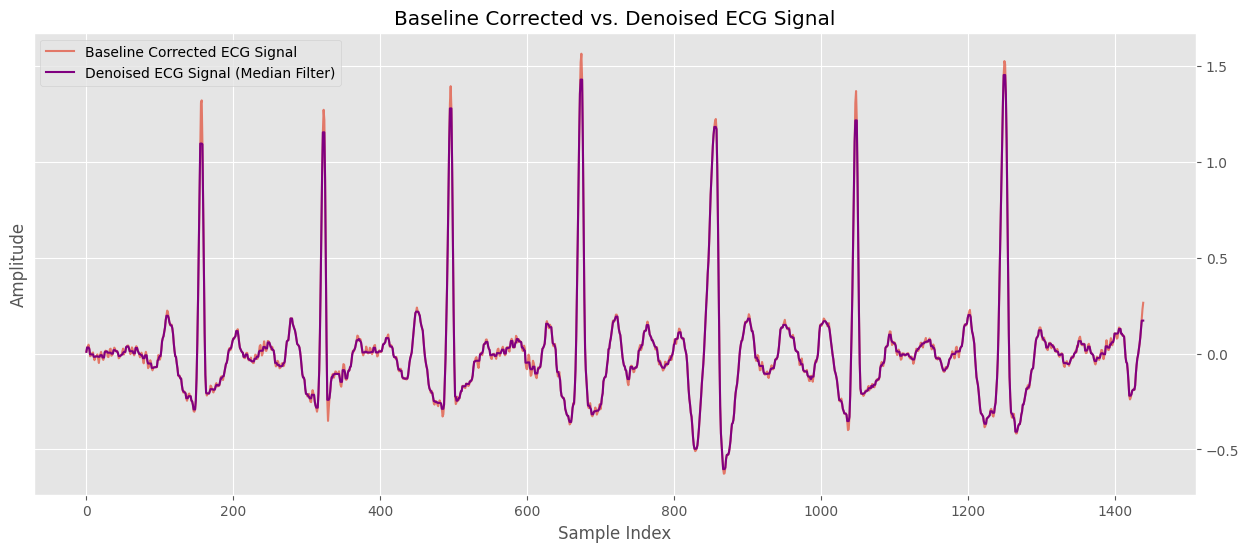

In [117]:
# Step 3: Display the original (baseline-corrected) and denoised signals
plt.figure(figsize=(15, 6))
plt.plot(corrected_ecg_signal, label='Baseline Corrected ECG Signal', alpha=0.7)
plt.plot(denoised_ecg_signal, label='Denoised ECG Signal (Median Filter)', color='purple')
plt.title('Baseline Corrected vs. Denoised ECG Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

**Parameter Selection:**

A median filter with a kernel size of 5 was applied to reduce short-duration noise in the baseline-corrected ECG signal. The relatively small kernel size helps reduce noise while preserving the important features of the ECG waveform.

**Interpretation:**

The median filter reduces short-duration fluctuations in the baseline-corrected ECG signal while preserving the main waveform features. The resulting denoised signal provides a cleaner signal for subsequent peak detection and feature extraction.

## **Part 4: Feature Extraction**
---
* Step 1: Create function to extract features (e.g., peak-to-peak interval, amplitude)
* Step 2: Apply feature extraction to the denoised signal
* Step 3: Display the extracted features

In [118]:
# Step 1: Create function to extract features
def extract_ecg_features(signal, peaks_indices):
    """
    Extracts features from an ECG signal based on detected peak indices.

    Args:
        signal (np.array): The processed ECG signal.
        peaks_indices (np.array): Indices of the detected peaks.

    Returns:
        dict: A dictionary containing extracted features.
    """
    features = {}

    # Peak amplitudes
    features['peak_amplitudes'] = signal[peaks_indices]

    # Peak-to-peak intervals (R-R intervals in ECG context)
    if len(peaks_indices) > 1:
        features['rr_intervals'] = np.diff(peaks_indices)
    else:
        features['rr_intervals'] = np.array([])

    print(f"Extracted {len(features['peak_amplitudes'])} peak amplitudes and {len(features['rr_intervals'])} RR intervals.")

    return features

print("Feature extraction function `extract_ecg_features` defined.")

Feature extraction function `extract_ecg_features` defined.


In [119]:
# Step 2: Apply feature extraction to the denoised signal
# For feature extraction, it's often best to use the denoised signal,
# but peaks were detected on the original signal in Part 1.
# It might be beneficial to re-detect peaks on the denoised signal for more accurate features.
# Let's re-detect peaks on the `denoised_ecg_signal`.

# Adjust these parameters if needed for the denoised signal
# Re-using the same parameters as initial peak detection for consistency.
# You might need to adjust 'height' and 'distance' based on the denoised signal's characteristics.
new_peaks, _ = find_peaks(denoised_ecg_signal, height=0.5, distance=100)
print(f'Re-detected {len(new_peaks)} peaks on the denoised signal for feature extraction.')

extracted_features = extract_ecg_features(denoised_ecg_signal, new_peaks)

print("Feature extraction completed.")

Re-detected 7 peaks on the denoised signal for feature extraction.
Extracted 7 peak amplitudes and 6 RR intervals.
Feature extraction completed.


Extracted Peak Amplitudes:
[1.0938881  1.15254005 1.277087   1.4272533  1.18050258 1.21463599
 1.45117403]

Extracted R-R Intervals (in samples):
[167 173 178 182 192 202]


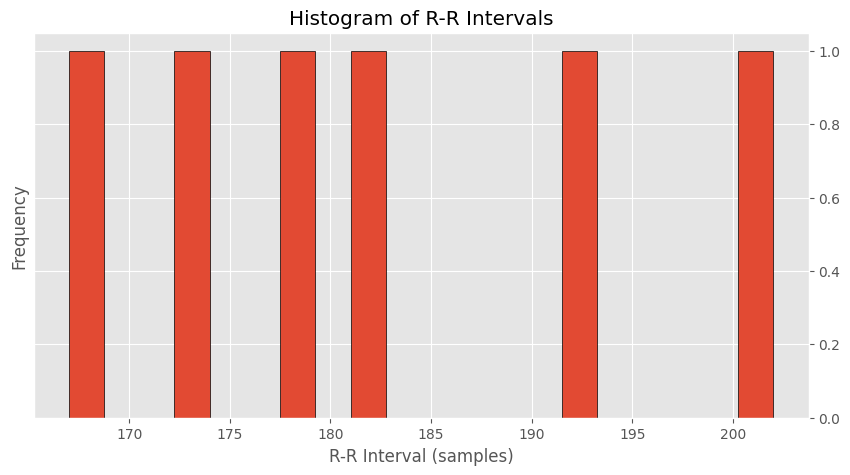

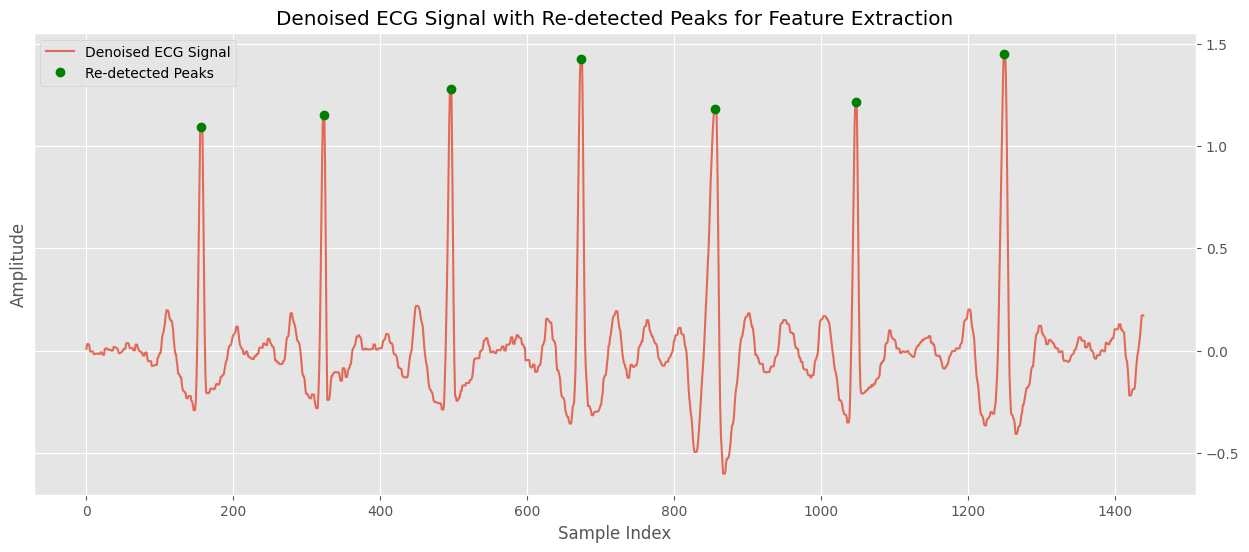

In [120]:
# Step 3: Display the extracted features

print("Extracted Peak Amplitudes:")
print(extracted_features['peak_amplitudes'])

if len(extracted_features['rr_intervals']) > 0:
    print("\nExtracted R-R Intervals (in samples):")
    print(extracted_features['rr_intervals'])

    # Visualize RR intervals as a histogram
    plt.figure(figsize=(10, 5))
    plt.hist(extracted_features['rr_intervals'], bins=20, edgecolor='black')
    plt.title('Histogram of R-R Intervals')
    plt.xlabel('R-R Interval (samples)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()
else:
    print("\nNo R-R intervals to display as less than two peaks were detected.")

# Optionally, visualize the denoised signal with the newly detected peaks
plt.figure(figsize=(15, 6))
plt.plot(denoised_ecg_signal, label='Denoised ECG Signal', alpha=0.8)
plt.plot(new_peaks, denoised_ecg_signal[new_peaks], "o", color='green', markersize=6, label='Re-detected Peaks')
plt.title('Denoised ECG Signal with Re-detected Peaks for Feature Extraction')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

**Interpretation:**

After baseline correction and denoising, 7 peaks were detected in the processed ECG signal. This produced 7 peak-amplitude values and 6 R-R intervals, since an interval is calculated between each pair of consecutive peaks. The R-R intervals obtained were [167, 173, 178, 182, 192, 202] samples. The intervals generally increase across the signal, indicating that the spacing between consecutive detected peaks becomes progressively larger. Since the sampling frequency is not specified in this analysis, the R-R intervals are reported in samples rather than seconds.